# Consumption Forecasting

This notebook builds a first machine learning model to predict hourly household electricity consumption.

The model uses temporal features and lagged consumption values to estimate future consumption.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"

sys.path.append(str(SRC_PATH))

from data_loader import load_consumption_data
from forecasting import run_consumption_forecast, compare_forecasting_models

In [3]:
DATA_PATH = PROJECT_ROOT / "data" / "simulated" / "synthetic_consumption_30_days.csv"

df = load_consumption_data(str(DATA_PATH))

df.head()

,datetime,consumption_kwh,hour,day,month,weekday
0,2025-01-01 00:00:00,0.124398,0,1,1,2
1,2025-01-01 01:00:00,0.177730,1,1,1,2
2,2025-01-01 02:00:00,0.123213,2,1,1,2
3,2025-01-01 03:00:00,0.157907,3,1,1,2
4,2025-01-01 04:00:00,0.115258,4,1,1,2


## Model training and evaluation

The forecasting pipeline creates temporal features, lag-based features, splits the data chronologically into training and test sets, trains a Random Forest regression model and evaluates the prediction error on the test period.

In [4]:
forecast_results = run_consumption_forecast(df)

metrics = forecast_results["metrics"]
results_df = forecast_results["results_df"]

metrics

{'mae': 0.041841903099041976, 'rmse': 0.052050648374286704}

In [5]:
print(f"MAE: {metrics['mae']:.4f} kWh")
print(f"RMSE: {metrics['rmse']:.4f} kWh")

MAE: 0.0418 kWh
RMSE: 0.0521 kWh


## Evaluation metrics

MAE measures the average absolute prediction error in kWh.

RMSE also measures prediction error, but penalizes larger errors more strongly. Therefore, RMSE is usually greater than or equal to MAE.

In [6]:
results_df[["actual_consumption_kwh", "predicted_consumption_kwh"]].head(20)

,actual_consumption_kwh,predicted_consumption_kwh
556,0.193660,0.187276
557,0.133849,0.171406
558,0.403125,0.389282
559,0.340111,0.391428
560,0.413493,0.367279
561,0.254218,0.309062
562,0.334056,0.289589
563,0.283249,0.331800
564,0.247068,0.267323
565,0.393520,0.293162


## Feature importance

Random Forest models can estimate the relative importance of each input feature.

This helps interpret which variables the model uses most when predicting hourly electricity consumption.

In [7]:
feature_importance_df = forecast_results["feature_importance_df"]

feature_importance_df

,feature,importance
0,consumption_kwh_lag_24,0.729913
1,hour,0.182185
2,consumption_kwh_lag_1,0.038194
3,weekday,0.019670
4,day,0.019413
5,is_weekend,0.010625
6,month,0.000000


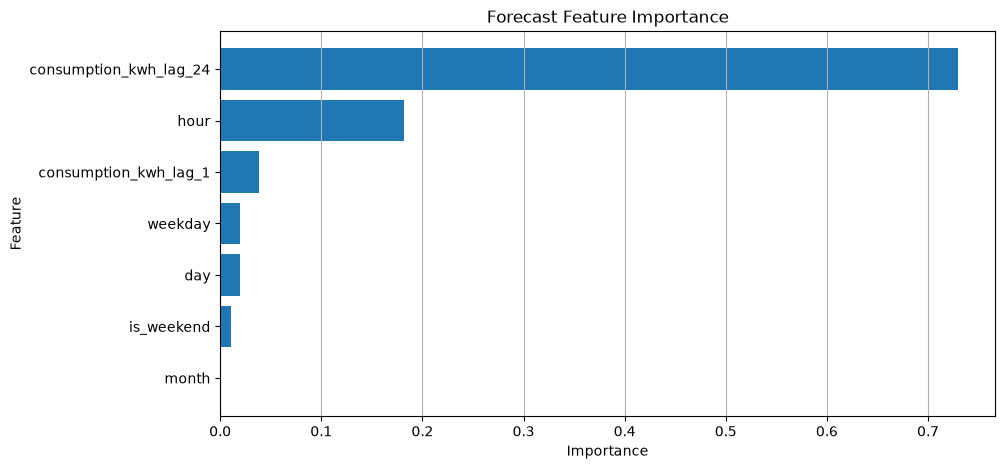

In [8]:
plt.figure(figsize=(10, 5))

plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])

plt.title("Forecast Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

The feature importance analysis shows that the model relies mainly on the previous day's consumption at the same hour (`consumption_kwh_lag_24`) and the hour of the day.

This is consistent with the synthetic dataset, which contains a strong repeated daily consumption pattern.

The `month` variable has zero importance because the current dataset only covers one month, so it does not provide useful information to the model.

## Model comparison

A Linear Regression model is used as a simple baseline and compared against the Random Forest model.

This allows us to check whether the more complex model actually improves the prediction accuracy.

In [9]:
comparison_df = compare_forecasting_models(df)

comparison_df

,model,mae,rmse
0,Random Forest,0.041842,0.052051
1,Linear_Regression,0.051068,0.063952


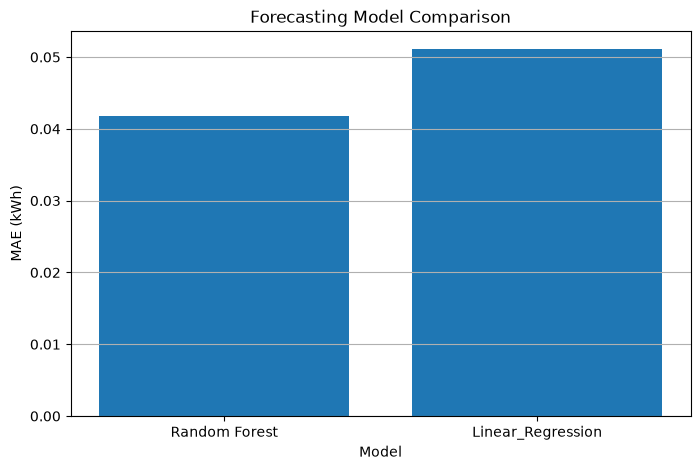

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(comparison_df["model"], comparison_df["mae"])

plt.title("Forecasting Model Comparison")
plt.xlabel("Model")
plt.ylabel("MAE (kWh)")
plt.grid(axis="y")
plt.show()

The Random Forest model achieves lower MAE and RMSE than the Linear Regression baseline.

This suggests that the consumption pattern contains non-linear relationships that are better captured by tree-based models.

Linear Regression is still useful as a baseline because it provides a simple reference model.

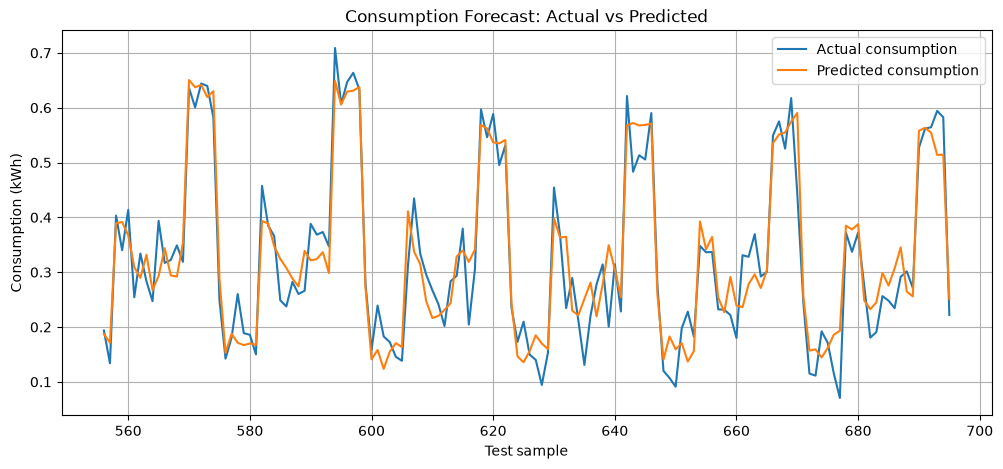

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(
    results_df.index, results_df["actual_consumption_kwh"], label="Actual consumption"
)

plt.plot(
    results_df.index,
    results_df["predicted_consumption_kwh"],
    label="Predicted consumption",
)

plt.title("Consumption Forecast: Actual vs Predicted")
plt.xlabel("Test sample")
plt.ylabel("Consumption (kWh)")
plt.grid(True)
plt.legend()
plt.show()

## Conclusion

The model is able to capture the main hourly consumption pattern using simple temporal and lag-based features.

The MAE represents the average hourly prediction error, while the RMSE penalizes larger errors more strongly.

The feature importance analysis confirms that the strongest predictors are the lagged consumption from the previous day and the hour of the day. This makes sense because household electricity consumption usually follows daily routines.

This is a first forecasting baseline. Future improvements could include real household consumption data, weather variables, electricity prices, holidays and longer historical periods.
